# Florentine families

In [1]:
import sys
import os
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import scipy
from scipy import stats
from scipy.special import expit
from tqdm import tqdm
np.random.seed(42)

## Network

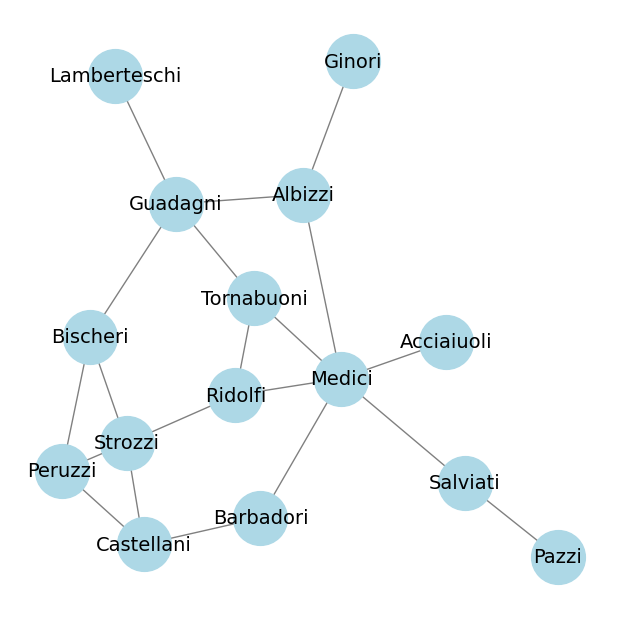

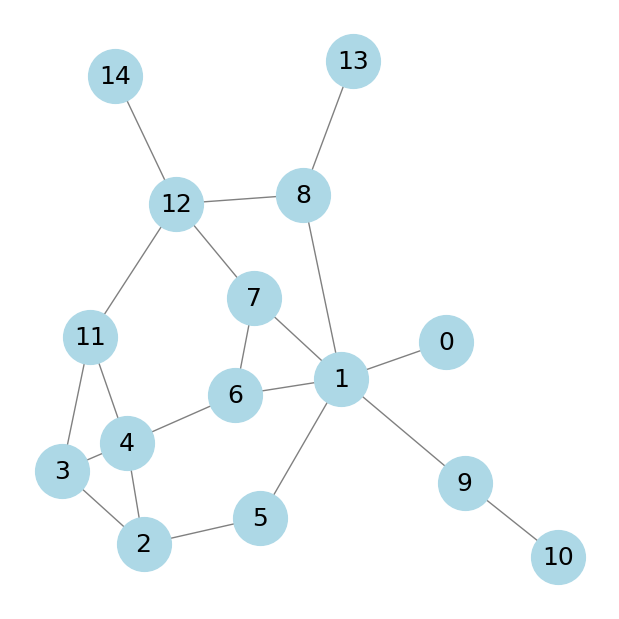

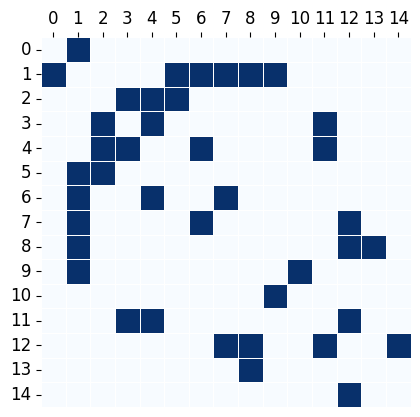

In [2]:
G = nx.florentine_families_graph()
pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(6,6))
nx.draw(G, pos=pos, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=14)
#plt.title("Florentine Families network")
plt.show()

G = nx.florentine_families_graph()
node_mapping = {node: i for i, node in enumerate(G.nodes())}
G = nx.relabel_nodes(G, node_mapping)
n = len(G.nodes)
plt.figure(figsize=(6,6))
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
nx.draw(G,  pos=pos_relabel, with_labels=True, node_color='lightblue', edge_color='gray', node_size=1500, font_size=18)
#plt.title("Florentine Families network with relabeled nodes")
plt.show()
#print("Map from original nodes to new nodes:")
#print(node_mapping)

Y = nx.to_numpy_array(G, dtype=float)

sns.heatmap(Y, annot=False, cmap="Blues", cbar=False, square=True, linewidths=0.5, linecolor='white')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top() 
plt.gca().tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=12)
#plt.title("Sociomatrix for Florentine families")
plt.show() 

## Code

### latentspacemodel.py

In [ ]:
import numpy as np
import re
from scipy.special import expit

class LatentSpaceModel:

    def __init__(
        self,
        Y, 
        d=2,
        params=None,
        node_attrs=None,
        edge_attrs=None
    ):
        # model specification
        self.Y = Y
        self.n = Y.shape[0]
        self.d = d
        # params: hyperparameters or fixed parameters
        self.params = params if params is not None else {}
        # covariates
        self.node_attrs = node_attrs if node_attrs is not None else {}
        self.edge_attrs = edge_attrs if edge_attrs is not None else {}
        # parsed model components
        self.node_terms = []
        self.edge_terms = []
        # estimation
        self.estimate_alpha_0 = True
        self.estimate_sigma2_alpha_0 = True
        self.estimate_alpha_node = True
        self.estimate_sigma2_alpha_node = True
        self.estimate_alpha_edge = True
        self.estimate_sigma2_alpha_edge = True
        self.estimate_W = True
        self.estimate_sigma2_W = True
        self.estimate_eta = True
        self.estimate_sigma2_eta = True
        self.estimate_kappa = True
        self.estimate_pi = True
        self.estimate_a = True

        self._set_default_hyperparams()
        self._process_params()


    def _set_default_hyperparams(self):
        defaults = {
            "omega_1": 1.0,
            "omega_2": 1.0,
            "omega_3": 1.0,
            "omega_4": 1.0,
            "omega_5": 1.0,
            "omega_6": 1.0,
            "omega_7": 1.0,
            "omega_8": 1.0,
            "mu_alpha_0": 0.0,
            "mu_eta": 0.0 * np.ones(self.n),
            "mu_w": 0.0 * np.ones(self.d),
        }
        for k, v in defaults.items():
            if k not in self.params:
                self.params[k] = v

    def _process_params(self):
        # Detect model structure from covariates
        if len(self.node_attrs) > 0:
            self.node_terms = list(self.node_attrs.keys())
            # set default hyperparameters for node coefficients
            p_node = len(self.node_terms)
            if "mu_alpha_node" not in self.params:
                self.params["mu_alpha_node"] = np.zeros(p_node)
        else:
            self.node_terms = []
            self.estimate_alpha_node = False
            self.estimate_sigma2_alpha_node = False
        if len(self.edge_attrs) > 0:
            self.edge_terms = list(self.edge_attrs.keys())
            # set default hyperparameters for edge coefficients
            p_edge = len(self.edge_terms)
            if "mu_alpha_edge" not in self.params:
                self.params["mu_alpha_edge"] = np.zeros(p_edge)
        else:
            self.edge_terms = []
            self.estimate_alpha_edge = False
            self.estimate_sigma2_alpha_edge = False

        # Fixed parameters (if provided)
        if "alpha_0" in self.params:
            self.estimate_alpha_0 = False
        if "sigma2_alpha_0" in self.params:
            self.estimate_sigma2_alpha_0 = False
        if "alpha_node" in self.params:
            self.estimate_alpha_node = False
        if "sigma2_alpha_node" in self.params:
            self.estimate_sigma2_alpha_node = False
        if "alpha_edge" in self.params:
            self.estimate_alpha_edge = False
        if "sigma2_alpha_edge" in self.params:
            self.estimate_sigma2_alpha_edge = False
        if "W" in self.params:
            self.estimate_W = False
        if "sigma2_W" in self.params:
            self.estimate_sigma2_W = False
        if "eta" in self.params:
            self.estimate_eta = False
        if "sigma2_eta" in self.params:
            self.estimate_sigma2_eta = False
        if "kappa" in self.params:
            self.estimate_kappa = False
        if "pi" in self.params:
            self.estimate_pi = False
        if "a" in self.params:
            self.estimate_a = False



    #---------------------------------------------------------------------
    #---------------------------------------------------------------------

    # Parameterization of latent positions
    def phi(self, w, kappa):
        if kappa == 0:
            if self.d == 1:
                return np.array([w[0], 0.0])
            if self.d == 2:
                return np.array([w[0], w[1], 0.0])
        if kappa == 1:
            if self.d == 1:
                u = np.pi * expit(w[0])
                return np.array([np.sin(u),np.cos(u)])
            if self.d == 2:
                u = np.pi * expit(w[0])
                v = 2*np.pi * expit(w[1])
                return np.array([
                    np.sin(u)*np.cos(v),
                    np.sin(u)*np.sin(v),
                    np.cos(u)])
        if kappa == -1:
            if self.d == 1:
                r = np.exp(w[0])
                return np.array([np.sinh(r),np.cosh(r)])
            if self.d == 2:
                r = np.exp(w[0])
                theta = 2*np.pi * expit(w[1])
                return np.array([
                    r*np.cos(theta),
                    r*np.sin(theta),
                    np.sqrt(1 + r**2)])
    ## Derivative
    def dphi(self, w, kappa):
        # returns matrix (d+1) x d
        if kappa == 0:
            if self.d == 1:
                return np.array([[1.0],[0.0]])
            if self.d == 2:
                return np.array([
                    [1.0, 0.0],
                    [0.0, 1.0],
                    [0.0, 0.0]])
        if kappa == 1:
            if self.d == 1:
                s = expit(w[0])
                ds = s * (1 - s)
                u = np.pi * s
                du = np.pi * ds
                return np.array([
                    [np.cos(u) * du],
                    [-np.sin(u) * du]])
            if self.d == 2:
                s = expit(w[0])
                ds = s * (1 - s)
                t = expit(w[1])
                dt = t * (1 - t)
                u = np.pi * s
                v = 2 * np.pi * t
                du = np.pi * ds
                dv = 2 * np.pi * dt
                return np.array([
                    [np.cos(u)*np.cos(v)*du, -np.sin(u)*np.sin(v)*dv],
                    [np.cos(u)*np.sin(v)*du,  np.sin(u)*np.cos(v)*dv],
                    [-np.sin(u)*du,           0.0]
                ])
        if kappa == -1:
            if self.d == 1:
                r = np.exp(w[0])
                dr = r
                return np.array([
                    [np.cosh(r) * dr],
                    [np.sinh(r) * dr]
                ])
            if self.d == 2:
                r = np.exp(w[0])
                dr = r
                s = expit(w[1])
                ds = s * (1 - s)
                theta = 2*np.pi*s
                dtheta = 2*np.pi*ds
                return np.array([
                    [dr*np.cos(theta), -r*np.sin(theta)*dtheta],
                    [dr*np.sin(theta),  r*np.cos(theta)*dtheta],
                    [r/np.sqrt(1+r**2)*dr, 0.0]
                ])
    #---------------------------------------------------------------------
    #---------------------------------------------------------------------

    def initialize_parameters(self, seed=42):

        rng = np.random.default_rng(seed)
        params = dict(self.params)

        omega_1,omega_2 = self.params["omega_1"],self.params["omega_2"]
        omega_3,omega_4 = self.params["omega_3"],self.params["omega_4"]
        omega_5,omega_6 = self.params["omega_5"],self.params["omega_6"]
        omega_7,omega_8 = self.params["omega_7"],self.params["omega_8"]

        mu_alpha_0 = self.params["mu_alpha_0"]
        mu_eta = self.params["mu_eta"]
        mu_W = self.params["mu_w"]
        # a
        if self.estimate_a:
            params["a"] = 1.0 / rng.gamma(omega_7, 1.0/omega_8)
        # pi
        if self.estimate_pi:
            a = params.get("a",self.params.get("a",1.0))
            params["pi"] = rng.dirichlet([a,a,a])
        # kappa
        if self.estimate_kappa:
            pi = params.get("pi",np.ones(3)/3)
            params["kappa"] = rng.choice([-1,0,1],p=pi)
        # sigma^2_alpha_0
        if self.estimate_sigma2_alpha_0:
            params["sigma2_alpha_0"] = 1.0 / rng.gamma(omega_1, 1.0/omega_2)
        # alpha_0
        if self.estimate_alpha_0:
            sigma2 = params.get("sigma2_alpha_0",1.0)
            params["alpha_0"] = rng.normal(mu_alpha_0,np.sqrt(sigma2))
        # sigma^2_eta
        if self.estimate_sigma2_eta:
            params["sigma2_eta"] = 1.0 / rng.gamma(omega_3, 1.0/omega_4)
        # eta
        if self.estimate_eta:
            sigma2 = params.get("sigma2_eta",1.0)
            params["eta"] = rng.normal(mu_eta,np.sqrt(sigma2),size=self.n)
        # sigma^2_W
        if self.estimate_sigma2_W:
            params["sigma2_W"] = 1.0 / rng.gamma(omega_5, 1.0/omega_6)
        # W
        if self.estimate_W:
            sigma2 = params.get("sigma2_W",1.0)
            params["W"] = rng.normal(mu_W,np.sqrt(sigma2),(self.n,self.d))
        # node coefficients
        if self.estimate_alpha_node:
            p = len(self.node_terms)
            mu = self.params["mu_alpha_node"]
            params["alpha_node"] = rng.normal(mu,1.0,size=p)
        # edge coefficients
        if self.estimate_alpha_edge:
            p = len(self.edge_terms)
            mu = self.params["mu_alpha_edge"]
            params["alpha_edge"] = rng.normal(mu,1.0,size=p)

        return params
    
    
    def __repr__(self):
        print("\nLatent Space Model")
        print("-"*40)
        # basic info
        print("Model specification")
        print(f"nodes: {self.n}")
        print(f"latent dimension: {self.d}")
        # covariates
        print("\nCovariates")
        if len(self.node_terms) > 0:
            print(f"node covariates ({len(self.node_terms)}): {self.node_terms}")
        else:
            print("node covariates: none")
        if len(self.edge_terms) > 0:
            print(f"edge covariates ({len(self.edge_terms)}): {self.edge_terms}")
        else:
            print("edge covariates: none")
        # estimation flags
        print("\nEstimated parameters")
        for k, v in vars(self).items():
            if k.startswith("estimate_") and v:
                print(" ", k.replace("estimate_",""))
        # fixed parameters
        print("\nFixed parameters")
        for k in self.params.keys():
            if not k.startswith("omega") and not k.startswith("mu"):
                print(" ", k)
        # hyperparameters
        print("\nHyperparameters")
        for k, v in self.params.items():
            if k.startswith("omega") or k.startswith("mu"):
                print(f" {k}: {v}")
        print("-"*40)


    def showDAG(self):
        raise NotImplementedError

    #---------------------------------------------------------------------
    #---------------------------------------------------------------------

    # Geodesic distances in ambient space
    def distance(self, zi, zj, kappa):
        if kappa == 0:
            return np.linalg.norm(zi - zj)
        elif kappa == 1:
            return np.arccos(np.clip(np.dot(zi, zj), -1, 1))
        elif kappa == -1:
            if self.d == 1:
                inner = zi[0]*zj[0] - zi[1]*zj[1]
            if self.d == 2:
                inner = zi[0]*zj[0] + zi[1]*zj[1] - zi[2]*zj[2]
            return np.arccosh(-inner)
        
    ## Derivative
    def ddistance_dzi(self, zi, zj, kappa):
        if kappa == 0:
            diff = zi - zj
            dist = np.linalg.norm(diff)
            return diff / dist
        elif kappa == 1:
            dot = np.clip(np.dot(zi, zj), -1.0, 1.0)
            denom = np.sqrt(1 - dot**2)
            denom = max(denom, 1e-10)
            return -zj / denom
        elif kappa == -1:
            if self.d == 1:
                inner = zi[0]*zj[0] - zi[1]*zj[1]
                grad_inner = np.array([zj[0], -zj[1]])
            if self.d == 2:
                inner = zi[0]*zj[0] + zi[1]*zj[1] - zi[2]*zj[2]
                grad_inner = np.array([zj[0], zj[1], -zj[2]])
            s = -inner
            denom = np.sqrt(s-1) * np.sqrt(s+1)
            denom = max(denom, 1e-12)
            return -grad_inner / denom

    #---------------------------------------------------------------------
    #---------------------------------------------------------------------

    # Predictor s_{i,j}
    def predictor(self, i, j, params, X_node=None, X_edge=None):
        W = params["W"]
        Zi = self.phi(W[i],self.kappa)
        Zj = self.phi(W[j],self.kappa)
        eta = params["eta"]
        alpha0 = params["alpha_0"]
        s = alpha0
        d = self.distance(Zi,Zj)
        if self.use_eta:
            mult = (np.exp(eta[i]) + np.exp(eta[j]))/2
            s -= mult*d
        else:
            s -= d
            
        return s
    
    #---------------------------------------------------------------------
    #---------------------------------------------------------------------

    # Loglikelihood
    def loglikelihood(self, Y, params, X_node=None, X_edge=None):
        ll = 0
        for i in range(self.n):
            for j in range(self.n):
                s = self.predictor(i, j, params, X_node, X_edge)
                y = Y[i, j]
                ll += y*s - np.log1p(np.exp(s))
        return ll

    # First derivative of loglikelihood
    ## First derivative of alpha_0
    def grad_alpha(self, params):
        Z = params["Z"]
        eta = params["eta"]
        g = 0
        for i in range(self.n):
            for j in range(i+1,self.n):
                s = self.predictor(i,j,params)
                p = expit(s)
                g += self.Y[i,j] - p
        return g
    ## First derivative of alpha_node
    def grad_alpha_node_cov(self, params, X_node):
        p = X_node.shape[1]
        g = np.zeros(p)
        for i in range(self.n):
            for j in range(i+1, self.n):
                s = self.predictor(i, j, params, X_node=X_node)
                pij = expit(s)
                g += (self.Y[i, j] - pij) * (X_node[i] + X_node[j])
        return g
    ## First derivative of alpha_edge
    def grad_alpha_edge(self, params, X_edge):
        p = X_edge.shape[2]
        g = np.zeros(p)
        for i in range(self.n):
            for j in range(i+1, self.n):
                s = self.predictor(i, j, params, X_edge=X_edge)
                pij = expit(s)
                g += (self.Y[i, j] - pij) * X_edge[i, j]
        return g
    ## First derivative of eta
    def grad_alpha_node(self, params):

        Z = params["Z"]
        eta = params["eta"]
        g = np.zeros(n)
        xi = np.exp(eta)
        for k in range(self.n):
            for i in range(self.n):
                if i == k:
                    continue
                if i < k:
                    y = self.Y[i, k]
                    s = self.predictor(i, k, params)
                    p = expit(s)
                    d = self.distance(Z[i], Z[k], params["kappa"])
                else:
                    y = self.Y[k, i]
                    s = self.predictor(k, i, params)
                    p = expit(s)
                    d = self.distance(Z[k], Z[i], params["kappa"])
                g[k] += (y - p) * d
            g[k] *= -0.5 * xi[k]
        return g

    ## First derivative w^i

    ## First derivative (total)


   
    # Second derivatives of loglikelihood
    ## Second derivative of alpha_0

    ## Second derivative of alpha_node

    ## Second derivative of alpha_edge

    ## Second derivative of eta

    ## Second derivative w^i

    ## Second derivative total



    #---------------------------------------------------------------------
    #---------------------------------------------------------------------

    # logprior







    #---------------------------------------------------------------------
    #---------------------------------------------------------------------

    # logposterior
    
    
    #---------------------------------------------------------------------
    #---------------------------------------------------------------------
    # Simulation (sample prior)
    def simulate(self, params=None, seed=None):
        rng = np.random.default_rng(seed)
        if params is None:
            params = self.initialize_parameters(n)
        Y = np.zeros((n,n))
        for i in range(n):
            for j in range(i+1,n):
                s = self.predictor(i,j,params)
                p = expit(s)
                y = rng.binomial(1,p)
                Y[i,j] = y
                Y[j,i] = y

        return Y, params

### inference.py

### afteranalyses.py

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

### Model $\mathbb{R}^2$

### Model $\mathbb{R}^3$

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

### Model $\mathbb{S}^2$

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

### Model $\mathbb{H}^2$